# Comparative Retrieval Benchmarking

This notebook evaluates the performance of the San Diego Land Use RAG system by benchmarking multiple retrieval architectures against the synthetic 50-query Ground Truth dataset generated in Notebook 08. 

We will test the following strategies:
1. **Baseline Lexical Search**: BM25.
2. **Baseline Semantic Search**: Standard pre-trained embeddings (`all-MiniLM-L6-v2`).
3. **Adapted Semantic Search**: Our custom, domain-adapted model (`san_diego_legal_bert`).

In [1]:
import os
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
base_path = '..'
ground_truth_path = f"{base_path}/data/processed/evaluation_ground_truth.json"
chunks_path = f"{base_path}/data/processed/san_diego_code_chunks.jsonl"
finetuned_model_path = f"{base_path}/models/san_diego_legal_bert_contrastive"

/Users/Aresh/Desktop/AAI 590/sd-land-use-rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/Aresh/Desktop/AAI 590/sd-land-use-rag/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 1. Data Loading
We load both the raw corpus (to build our local evaluation indices) and our newly minted 50 evaluation queries.

In [2]:
print("Loading Data...")

# Load Evaluation Queries
with open(ground_truth_path, 'r') as f:
    evaluation_data = json.load(f)
eval_df = pd.DataFrame(evaluation_data)
print(f"Loaded {len(eval_df)} evaluation queries.")

# Load full corpus text
corpus = []
corpus_chunks = []
with open(chunks_path, 'r') as f:
    for i, line in enumerate(f):
        data = json.loads(line)
        corpus.append(data['text'])
        # Maintain a map to match original JSON metadata later
        corpus_chunks.append({
            'index': i,
            'text': data['text'],
            'chunk_index': data.get('metadata', {}).get('chunk_index', i) # Using loop index as fallback
        })
print(f"Loaded {len(corpus)} total municipal code documents into the evaluation corpus.")

Loading Data...
Loaded 50 evaluation queries.
Loaded 52384 total municipal code documents into the evaluation corpus.


## 2. Retriever Initialization
We initialize the models required for our comparative runs: BM25, a Baseline Dense model, and our Fine-Tuned Dense model.

In [3]:
print("Initializing Retrievers (This may take a minute to load models and embed corpus)...\n")

# 1. Setup Keyword Search (BM25)
print("Building BM25 Index...")
tokenized_corpus = [doc.lower().split() for doc in corpus]
bm25_model = BM25Okapi(tokenized_corpus)

# 2. Setup Baseline Semantic Retriever (MiniLM)
print("Loading Baseline Model (all-MiniLM-L6-v2) and embedding corpus...")
baseline_model = SentenceTransformer('all-MiniLM-L6-v2')
baseline_corpus_embeddings = baseline_model.encode(corpus, convert_to_tensor=True, show_progress_bar=True)

# 3. Setup Fine-Tuned Semantic Retriever (Legal-BERT)
print("Loading Custom Model (san_diego_legal_bert) and embedding corpus...")
if os.path.exists(finetuned_model_path):
    custom_model = SentenceTransformer(finetuned_model_path)
    custom_corpus_embeddings = custom_model.encode(corpus, convert_to_tensor=True, show_progress_bar=True)
else:
    print("\nWARNING: Custom model not found. Run Stage 07 to fine-tune the model first!")
    custom_model = None

Initializing Retrievers (This may take a minute to load models and embed corpus)...

Building BM25 Index...
Loading Baseline Model (all-MiniLM-L6-v2) and embedding corpus...


Batches: 100%|██████████| 1637/1637 [00:28<00:00, 57.33it/s] 


Loading Custom Model (san_diego_legal_bert) and embedding corpus...


Batches: 100%|██████████| 1637/1637 [01:33<00:00, 17.58it/s] 


## 3. Evaluation Functions

We define core retrieval functions that return the top `k` indices for a given query, along with scoring mechanisms for **Hit Rate** and **Mean Reciprocal Rank (MRR)**.

In [4]:
def retrieve_bm25(query, k=10):
    tokenized_query = query.lower().split()
    scores = bm25_model.get_scores(tokenized_query)
    top_k_indices = np.argsort(scores)[::-1][:k]
    return top_k_indices

def retrieve_dense(query, model, corpus_embeddings, k=10):
    query_embedding = model.encode(query, convert_to_tensor=True)
    hits = util.semantic_search(query_embedding, corpus_embeddings, top_k=k)[0]
    return [hit['corpus_id'] for hit in hits]

def calculate_mrr(retrieved_indices, ground_truth_text):
    """
    Because the chunk_index in our dataset was occasionally stripped by earlier scripts,
    we calculate MRR using an exact string match of the ground_truth_text.
    """
    for rank, idx in enumerate(retrieved_indices):
        if corpus[idx] == ground_truth_text:
            return 1.0 / (rank + 1)
    return 0.0

def calculate_hit_rate(retrieved_indices, ground_truth_text, k):
    """
    Returns 1 if the exact ground_truth text is found within the top K results.
    """
    for idx in retrieved_indices[:k]:
        if corpus[idx] == ground_truth_text:
            return 1
    return 0

## 4. Benchmarking Loop
We run every synthetic query against all three distinct retrieval systems to log their individual MRRs and HitRates.

In [5]:
results = []

print("Starting Evaluation Benchmarks...")
for index, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    query = row['query']
    true_text = row['source_text']
    
    # --- 1. BM25 --- 
    bm25_indices = retrieve_bm25(query, k=10)
    bm25_mrr = calculate_mrr(bm25_indices, true_text)
    bm25_hr5 = calculate_hit_rate(bm25_indices, true_text, k=5)
    
    # --- 2. Baseline Dense (MiniLM) ---
    base_indices = retrieve_dense(query, baseline_model, baseline_corpus_embeddings, k=10)
    base_mrr = calculate_mrr(base_indices, true_text)
    base_hr5 = calculate_hit_rate(base_indices, true_text, k=5)
    
    # --- 3. Custom Legal-BERT ---
    if custom_model:
        custom_indices = retrieve_dense(query, custom_model, custom_corpus_embeddings, k=10)
        custom_mrr = calculate_mrr(custom_indices, true_text)
        custom_hr5 = calculate_hit_rate(custom_indices, true_text, k=5)
    else:
        custom_mrr = 0
        custom_hr5 = 0
        
    results.append({
        'query_id': row['query_id'],
        'bm25_mrr': bm25_mrr,
        'bm25_hr5': bm25_hr5,
        'baseline_dense_mrr': base_mrr,
        'baseline_dense_hr5': base_hr5,
        'custom_dense_mrr': custom_mrr,
        'custom_dense_hr5': custom_hr5
    })

Starting Evaluation Benchmarks...


100%|██████████| 50/50 [00:09<00:00,  5.44it/s]


## 5. Performance Report
Summarizing the metrics to derive our final Capstone conclusion on system efficacy.

/var/folders/4d/tryvzz8s26l1q8hcjs0j79ww0000gn/T/ipykernel_5416/3649603225.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_summary, x="Model", y="Mean Reciprocal Rank (MRR)", ax=ax[0], palette="viridis")
/var/folders/4d/tryvzz8s26l1q8hcjs0j79ww0000gn/T/ipykernel_5416/3649603225.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_summary, x="Model", y="Hit Rate @ 5", ax=ax[1], palette="viridis")



================ FINAL BENCHMARK RESULTS ================

                      Model  Mean Reciprocal Rank (MRR)  Hit Rate @ 5
        Keyword List (BM25)                    0.043333          0.04
    Out-of-the-Box (MiniLM)                    0.191413          0.30
Domain Adapted (Legal-BERT)                    0.501190          0.72



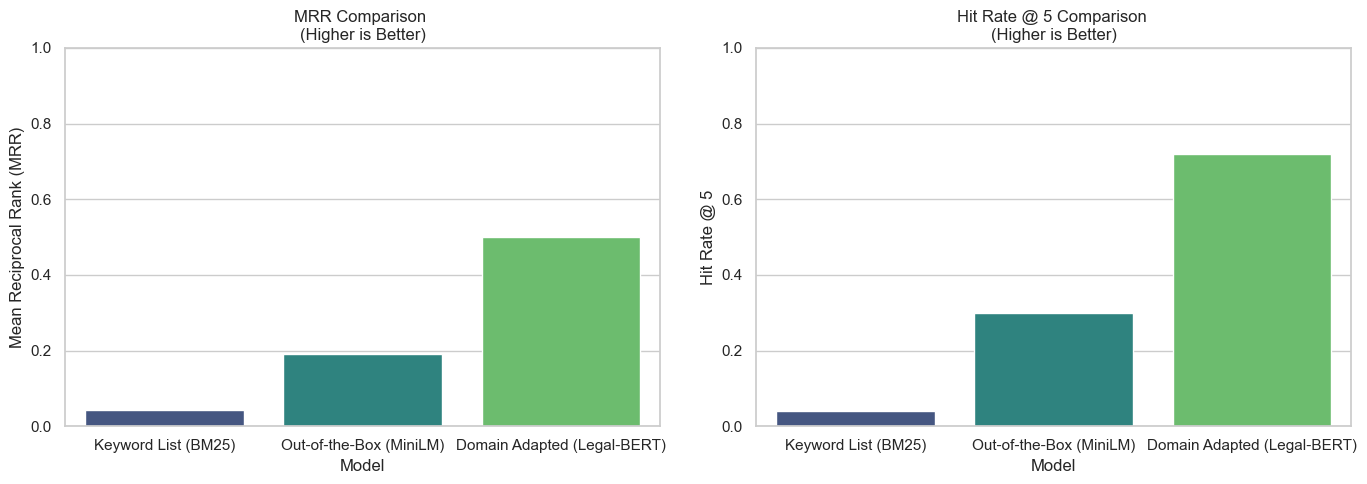

In [6]:
results_df = pd.DataFrame(results)

metrics_summary = pd.DataFrame({
    'Model': ['Keyword List (BM25)', 'Out-of-the-Box (MiniLM)', 'Domain Adapted (Legal-BERT)'],
    'Mean Reciprocal Rank (MRR)': [
        results_df['bm25_mrr'].mean(),
        results_df['baseline_dense_mrr'].mean(),
        results_df['custom_dense_mrr'].mean()
    ],
    'Hit Rate @ 5': [
        results_df['bm25_hr5'].mean(),
        results_df['baseline_dense_hr5'].mean(),
        results_df['custom_dense_hr5'].mean()
    ]
})

print("\n================ FINAL BENCHMARK RESULTS ================\n")
print(metrics_summary.to_string(index=False))
print("\n=========================================================")

# Optional Graphing
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=metrics_summary, x="Model", y="Mean Reciprocal Rank (MRR)", ax=ax[0], palette="viridis")
ax[0].set_title("MRR Comparison \n(Higher is Better)")
ax[0].set_ylim(0, 1)

sns.barplot(data=metrics_summary, x="Model", y="Hit Rate @ 5", ax=ax[1], palette="viridis")
ax[1].set_title("Hit Rate @ 5 Comparison \n(Higher is Better)")
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()